In [1]:
import sys
!{sys.executable} -m pip install yfinance --quiet
import yfinance as yf

In [2]:
sp_500 = yf.Ticker("^GSPC")

In [3]:
sp_500 = sp_500.history(period = "max")

In [4]:
sp_500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-04-13 00:00:00-04:00,6806.470215,6887.000000,6790.020020,6886.240234,4785840000,0.0,0.0
2026-04-14 00:00:00-04:00,6910.200195,6969.419922,6905.169922,6967.379883,5032380000,0.0,0.0
2026-04-15 00:00:00-04:00,6978.169922,7026.240234,6967.129883,7022.950195,5278610000,0.0,0.0


<Axes: xlabel='Date'>

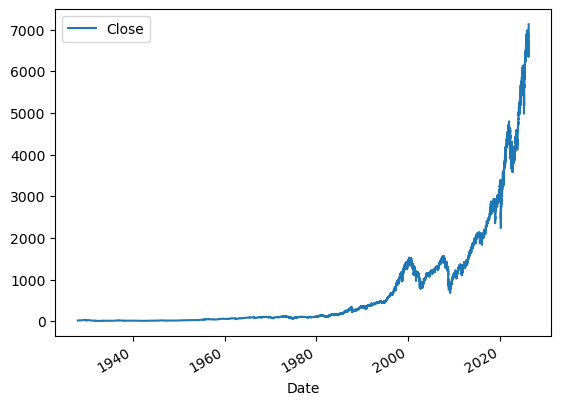

In [5]:
sp_500.plot.line(y="Close", use_index=True)

In [6]:
del sp_500["Dividends"]
del sp_500['Stock Splits']

In [7]:
sp_500["Tomorrow"] = sp_500["Close"].shift(-1)

In [8]:
sp_500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2026-04-13 00:00:00-04:00,6806.470215,6887.000000,6790.020020,6886.240234,4785840000,6967.379883
2026-04-14 00:00:00-04:00,6910.200195,6969.419922,6905.169922,6967.379883,5032380000,7022.950195
2026-04-15 00:00:00-04:00,6978.169922,7026.240234,6967.129883,7022.950195,5278610000,7041.279785


In [9]:
sp_500["Target"] = (sp_500["Tomorrow"] > sp_500["Close"]).astype(int)

In [10]:
sp_500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2026-04-13 00:00:00-04:00,6806.470215,6887.000000,6790.020020,6886.240234,4785840000,6967.379883,1
2026-04-14 00:00:00-04:00,6910.200195,6969.419922,6905.169922,6967.379883,5032380000,7022.950195,1
2026-04-15 00:00:00-04:00,6978.169922,7026.240234,6967.129883,7022.950195,5278610000,7041.279785,1


In [11]:
sp_500 = sp_500.loc['1990-01-01':].copy()

In [12]:
sp_500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2026-04-13 00:00:00-04:00,6806.470215,6887.000000,6790.020020,6886.240234,4785840000,6967.379883,1
2026-04-14 00:00:00-04:00,6910.200195,6969.419922,6905.169922,6967.379883,5032380000,7022.950195,1
2026-04-15 00:00:00-04:00,6978.169922,7026.240234,6967.129883,7022.950195,5278610000,7041.279785,1


In [13]:
from sklearn.ensemble import RandomForestClassifier 

model = RandomForestClassifier(n_estimators = 120, min_samples_split = 100, random_state=1)

train = sp_500.iloc[:-100]
test = sp_500.iloc[-100:]
predictors = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])

RandomForestClassifier(min_samples_split=100, n_estimators=120, random_state=1)

In [14]:
from sklearn.metrics import precision_score
preds = model.predict(test[predictors])

In [15]:
import pandas as pd
preds = pd.Series(preds, index=test.index)

In [16]:
precision_score(test["Target"], preds)

0.6333333333333333

In [17]:
combined = pd.concat([test["Target"], preds], axis=1)

<Axes: xlabel='Date'>

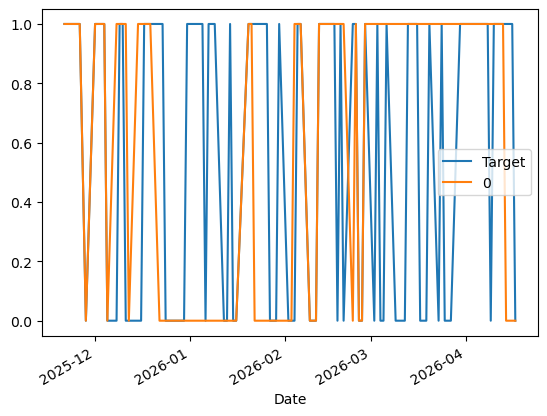

In [18]:
combined.plot()

In [19]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [20]:
def backtest(data, model, predictors, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:i+step].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)

In [21]:
predictions = backtest(sp_500, model, predictors)

In [22]:
predictions["Predictions"].value_counts()

Predictions
0    3963
1    2677
Name: count, dtype: int64

In [23]:
precision_score(predictions["Target"], predictions['Predictions'])

0.5304445274561076

In [24]:
predictions['Target'].value_counts() / predictions.shape[0]

Target
1    0.5375
0    0.4625
Name: count, dtype: float64

In [25]:
horizons = [2, 5, 60, 250, 100]
new_predictors = []

for horizon in horizons:
    rolling_averages = sp_500.rolling(horizon).mean()

    ratio_column = f"Close_ratio_{horizon}"
    sp_500[ratio_column] = sp_500["Close"]/rolling_averages["Close"]

    trend_column = f"Trend_{horizon}"
    sp_500[trend_column] = sp_500.shift(1).rolling(horizon).sum()['Target']

    new_predictors += [ratio_column, trend_column]

In [27]:
sp_500 = sp_500.dropna()

In [29]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [30]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1]
    preds[preds >= .6] = 1
    preds[preds < 0.6] = 0
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [31]:
predictions = backtest(sp_500, model, new_predictors)

In [33]:
predictions["Predictions"].value_counts()

Predictions
0.0    5408
1.0     981
Name: count, dtype: int64

In [34]:
precision_score(predictions["Target"], predictions['Predictions'])

0.5749235474006116